In [38]:
# train a decision tree on the palmer penguin set

from palmerpenguins import load_penguins

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
penguins = load_penguins()

In [3]:
type(penguins)

pandas.DataFrame

In [138]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [140]:
# print all unique islands
unique_islands = penguins['island'].unique()
print(unique_islands)

<ArrowStringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str


In [5]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [6]:
# data cleaning: drop missing values
penguins = penguins.dropna()


In [9]:
X = penguins.drop("species", axis=1)
y = penguins["species"]

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
dt_classifier = DecisionTreeClassifier(max_depth=3)
dt_classifier.fit(X_train, y_train)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [22]:
# Evaluate the model
y_pred = dt_classifier.predict(X_test)

# Evaluate the model

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       0.94      1.00      0.97        31
   Chinstrap       1.00      0.89      0.94        18
      Gentoo       1.00      1.00      1.00        18

    accuracy                           0.97        67
   macro avg       0.98      0.96      0.97        67
weighted avg       0.97      0.97      0.97        67



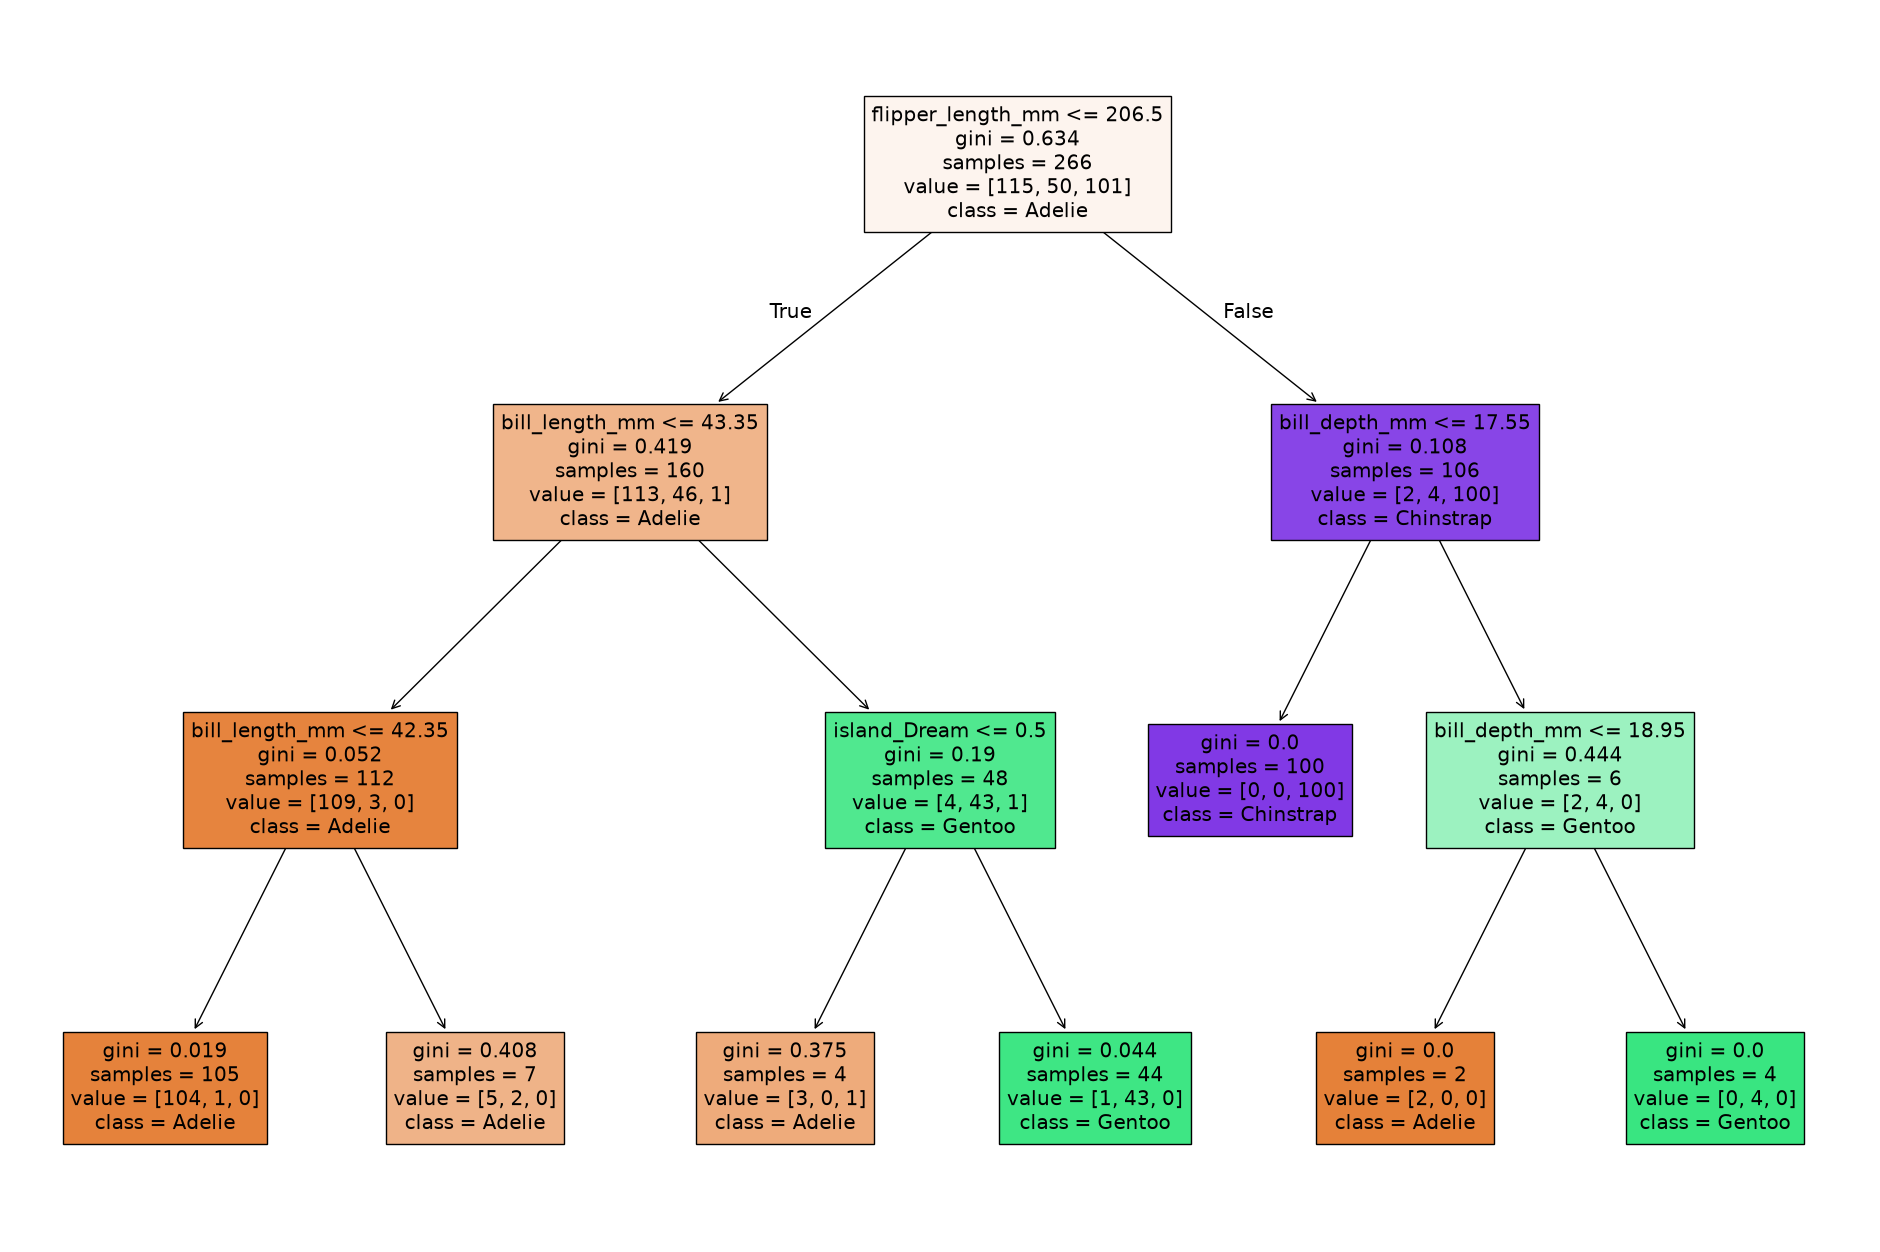

In [23]:
# show the resulting tree

plt.figure(figsize=(24,16))
plot_tree(dt_classifier, filled=True, feature_names=X.columns, class_names=y.unique())
plt.show()

In [24]:
# print the number of leaves
print("Number of leaves:", dt_classifier.get_n_leaves())

Number of leaves: 7


In [136]:
# train multiple decision trees with different degree of regularization and then print the score acc_test - lambda*(complexity) where the complexity is measured as the number of leaves
lambda_reg = 1.0
values = []
for max_depth in range(1, 11):
    dt_classifier = DecisionTreeClassifier(max_depth=max_depth)
    dt_classifier.fit(X_train, y_train)
    acc_test = dt_classifier.score(X_test, y_test)
    complexity = dt_classifier.get_n_leaves()
    values.append(acc_test - lambda_reg * complexity)
    print(f"max_depth={max_depth} leaves={complexity} acc={acc_test}: {acc_test - lambda_reg * complexity}")

max_depth=1 leaves=2 acc=0.7313432835820896: -1.2686567164179103
max_depth=2 leaves=4 acc=0.9701492537313433: -3.029850746268657
max_depth=3 leaves=7 acc=0.9701492537313433: -6.029850746268656
max_depth=4 leaves=11 acc=1.0: -10.0
max_depth=5 leaves=13 acc=1.0: -12.0
max_depth=6 leaves=13 acc=0.9850746268656716: -12.014925373134329
max_depth=7 leaves=13 acc=1.0: -12.0
max_depth=8 leaves=13 acc=0.9850746268656716: -12.014925373134329
max_depth=9 leaves=13 acc=1.0: -12.0
max_depth=10 leaves=13 acc=1.0: -12.0


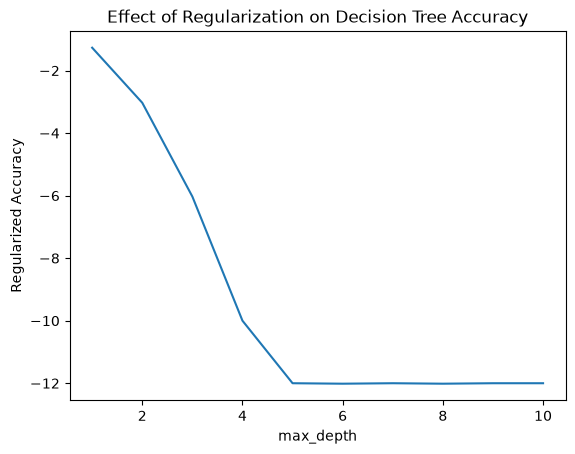

In [137]:
plt.plot(range(1, 11), values)
plt.xlabel("max_depth")
plt.ylabel("Regularized Accuracy")
plt.title("Effect of Regularization on Decision Tree Accuracy")
plt.show()

In [130]:
# 1. Load and preprocess data
penguins = load_penguins().dropna()
X = pd.get_dummies(penguins.drop("species", axis=1), drop_first=True)
y = penguins["species"]
feature_names = X.columns.tolist()
target_names = y.unique().tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [131]:

# Scale continuous features (essential for regularized logistic regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [114]:

# 2. Train candidate models across a range of regularizations (C)
c_values = np.logspace(-2.5, 3.5, 20)
candidate_lr_models = []

for c in c_values:
    # L1 penalty using saga or liblinear solver forces weights to 0
    clf = LogisticRegression(l1_ratio=1.0, C=c, solver='saga', max_iter=5000, random_state=42)
    clf.fit(X_train_scaled, y_train)
    
    acc_test = clf.score(X_test_scaled, y_test)
    
    # Complexity measure Options:
    # Option A: Number of non-zero coefficients (L0 equivalent)
    # Option B: Sum of absolute values of weights (L1 norm)
    l1_norm = np.sum(np.abs(clf.coef_))
    non_zero_weights = np.sum(clf.coef_ != 0)
    
    candidate_lr_models.append({
        'model': clf,
        'acc_test': acc_test,
        'omega': non_zero_weights,  # or non_zero_weights
        'c_val': c
    })


In [115]:

# 3. Model selector for a given user slider value (lambda)
scores = []
def get_best_logistic_model(lambda_param, models):
    best_score = -float('inf')
    best_candidate = None
    
    for item in models:
        # acc_test - lambda * Omega(f)
        score = item['acc_test'] - (lambda_param * item['omega'])
        scores.append(score)
        if score > best_score:
            best_score = score
            best_candidate = item
            
    return best_candidate

# Example evaluation
lambda_val = 0.02
best_lr = get_best_logistic_model(lambda_val, candidate_lr_models)

print(f"Selected C value: {best_lr['c_val']:.4f}")
print(f"Model Omega (Complexity): {best_lr['omega']:.4f}")
print(f"Test Accuracy: {best_lr['acc_test']:.4f}")

Selected C value: 0.0580
Model Omega (Complexity): 5.0000
Test Accuracy: 0.9701


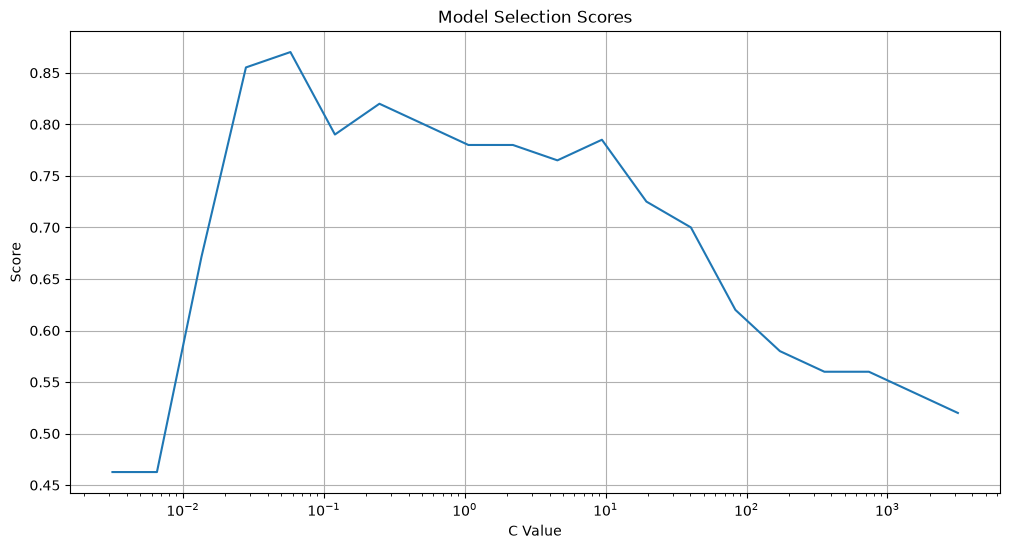

In [116]:
# plot scores
plt.figure(figsize=(12, 6))
plt.plot(c_values, scores)
plt.title('Model Selection Scores')
plt.xlabel('C Value')
plt.ylabel('Score')
plt.xscale('log')
plt.grid()
plt.show()

In [117]:
# print the number of params of the model below a certain threshold
threshold = 10000
for item in candidate_lr_models:
    if item['omega'] < threshold:
        print(f"Model with C={item['c_val']} has complexity {item['omega']}")

Model with C=0.0031622776601683794 has complexity 0
Model with C=0.006543189129712969 has complexity 0
Model with C=0.01353876180022544 has complexity 3
Model with C=0.02801356761198867 has complexity 5
Model with C=0.05796393953384967 has complexity 5
Model with C=0.11993539462092344 has complexity 9
Model with C=0.24816289228368252 has complexity 9
Model with C=0.5134832907437549 has complexity 10
Model with C=1.062467830894041 has complexity 11
Model with C=2.1983926488622894 has complexity 11
Model with C=4.548777947003778 has complexity 11
Model with C=9.412049672680661 has complexity 10
Model with C=19.47483039908755 has complexity 13
Model with C=40.29611320200396 has complexity 15
Model with C=83.37822234717883 has complexity 19
Model with C=172.52105499420392 has complexity 21
Model with C=356.9698846826063 has complexity 22
Model with C=738.6199822079358 has complexity 22
Model with C=1528.3067326587689 has complexity 23
Model with C=3162.2776601683795 has complexity 24


In [134]:
def generate_lr_weights_plot(lambda_val, models):
    """Generates heatmap matrix highlighting non-zero weights vs eliminated zero-weights."""
    best_model = get_best_logistic_model(lambda_val, models)
    weights = best_model['model'].coef_  # Shape: (n_classes, n_features)

    fig, ax = plt.subplots(figsize=(11, 4))
    im = ax.imshow(weights, aspect='auto', vmin=-np.max(np.abs(weights)), vmax=np.max(np.abs(weights)))
    
    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Coefficient Weight Strength", rotation=270, labelpad=15)

    # Ticks and Labels
    ax.set_xticks(np.arange(len(feature_names)))
    ax.set_yticks(np.arange(len(target_names)))
    ax.set_xticklabels(feature_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(target_names, fontsize=9)

    # Overlay text values & draw red borders on Zero Weights
    for i in range(len(target_names)):
        for j in range(len(feature_names)):
            val = weights[i, j]
            is_zero = np.isclose(val, 0, atol=1e-5)
            
            # Annotate value
            text_color = "black" if abs(val) < 0.5 else "white"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=7.5, fontweight='bold')
            
            # Highlight eliminated (Zero) features with red box outlines
            if is_zero:
                rect = plt.Rectangle((j - 0.45, i - 0.45), 0.9, 0.9, fill=False, edgecolor='#e11d48', linewidth=2)
                ax.add_patch(rect)

    ax.set_title("Feature Weights Matrix (L1 Regularized Zero Weights Boxed in Red)", fontsize=11, fontweight='bold', pad=15)
    plt.show()


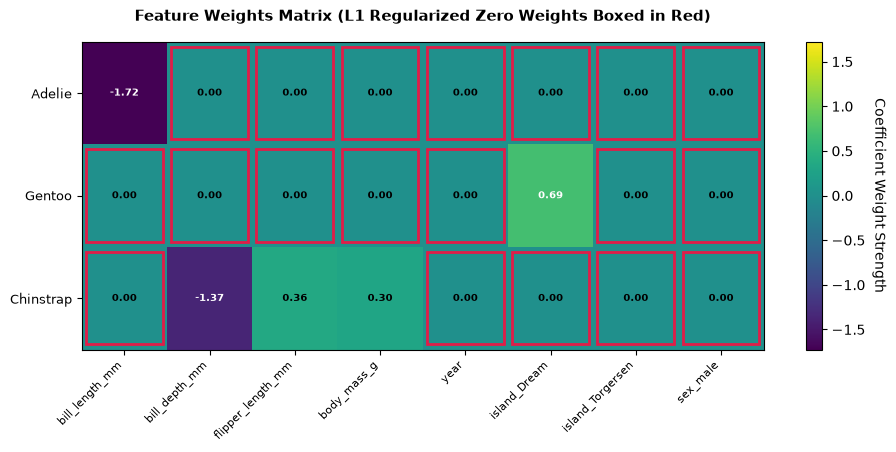

In [135]:
generate_lr_weights_plot(0.02, candidate_lr_models)